# Social Vulnerability and Health Outcomes in America — Phase 1

**Author:** Mohammad Haider 
**Date:** April 2026 
**Phase:** 1 of 4 — Foundation

---

## The Question

Can socioeconomic status serve as a predictor of health outcomes? While health outcomes across America can vary dramatically, they can also be influenced by socioeconomic and political factors. Every diagnosis, crisis, or preventative treatment is indicative of a larger system; one where outcomes can be strongly correlated with where someone lives or what means they possess.

This analysis joins two CDC datasets at the census tract level — the **Social Vulnerability Index (SVI)** and **PLACES** — to analyze potential such relationships.

## What This Notebook Does

1. Downloads SVI and PLACES data from CDC (one-time, cached locally)
2. Joins them on census tract FIPS code
3. Computes correlations between vulnerability dimensions and health outcomes
4. Builds a national choropleth showing the geography of the disparity
5. Surfaces state-level patterns

## Caveats Up Front

- This is **observational data**. We can describe associations but **not causation**.
- Both datasets are **estimates** with their own uncertainty bounds.
- Census tract is a coarse unit — there's variation within tracts we can't see.

## Setup

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS = PROJECT_ROOT / 'outputs'

for p in [DATA_RAW, DATA_PROCESSED, OUTPUTS / 'figures']:
    p.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Pandas version: {pd.__version__}')

Project root: c:\Users\haidm\Desktop\social-impact-analysis
Pandas version: 3.0.2


## Step 1: Download the Data

**SVI 2022** (most recent): A CSV with 16 vulnerability indicators per census tract, plus four summary themes (socioeconomic, household, racial/ethnic minority, housing/transportation) and an overall ranking.

**PLACES 2024 release** (most recent): Estimated prevalence of 36 chronic conditions and behaviors per census tract.

Both datasets are public, no API key needed. We cache locally so we only download once.

**Important:** URLs occasionally change. If a download fails, check:
- SVI: https://www.atsdr.cdc.gov/placeandhealth/svi/data_documentation_download.html
- PLACES: https://www.cdc.gov/places/index.html

In [52]:
# CDC datasets are downloaded manually from:
#   SVI:    https://svi.cdc.gov/dataDownloads/data-download.html
#   PLACES: https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-Census-Tract-D/cwsq-ngmh
# Saved locally so the notebook is fully reproducible.

svi_path = DATA_RAW / 'svi_2022.csv'
places_path = DATA_RAW / 'places_2024.csv'

assert svi_path.exists(), f'Missing: {svi_path}. See URLs in cell comment above.'
assert places_path.exists(), f'Missing: {places_path}. See URLs in cell comment above.'

print(f'SVI: {svi_path.stat().st_size / 1e6:.1f} MB')
print(f'PLACES: {places_path.stat().st_size / 1e6:.1f} MB')

SVI: 61.1 MB
PLACES: 867.9 MB


## Step 2: Load and Inspect SVI

In [53]:
# Load SVI - keep FIPS as string to preserve leading zeros
svi = pd.read_csv(svi_path, dtype={'FIPS': str, 'STCNTY': str})
print(f'SVI shape: {svi.shape}')
svi.head(3)

SVI shape: (84120, 158)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,E_POV150,M_POV150,E_UNEMP,M_UNEMP,E_HBURD,M_HBURD,E_NOHSDP,M_NOHSDP,E_UNINSUR,M_UNINSUR,E_AGE65,...,M_ASIAN,E_AIAN,M_AIAN,E_NHPI,M_NHPI,E_TWOMORE,M_TWOMORE,E_OTHERRACE,M_OTHERRACE,EP_NOINT,MP_NOINT,EP_AFAM,MP_AFAM,EP_HISP,MP_HISP,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,01001,Autauga County,01001020100,Census Tract 201; Autauga County; Alabama,3.793569,1865,368,733,114,700,114,402,184,19,19,125,74,205,78,153,89,363,...,65,0,13,0,13,103,75,0,13,8.1,7.2,11.2,7.3,4.3,3.8,2.4,3.4,0.0,2.0,0.0,2.0,5.5,4.2,0.0,2.0
1,1,Alabama,AL,01001,Autauga County,01001020200,Census Tract 202; Autauga County; Alabama,1.282174,1861,396,680,97,544,101,239,144,51,39,95,56,129,48,129,85,293,...,13,0,13,0,13,135,119,8,16,21.5,10.9,56.0,11.2,0.1,0.3,0.0,2.0,0.0,2.0,0.0,2.0,7.3,6.3,0.4,0.9
2,1,Alabama,AL,01001,Autauga County,01001020300,Census Tract 203; Autauga County; Alabama,2.065364,3492,593,1431,213,1305,227,773,335,33,38,313,128,244,114,175,97,470,...,19,0,13,0,13,148,182,0,13,10.3,5.9,25.1,13.0,1.3,1.7,0.3,0.5,0.0,1.1,0.0,1.1,4.2,5.2,0.0,1.1


In [54]:
# The columns we care about for Phase 1:
# - FIPS: census tract identifier
# - STATE, COUNTY: human-readable location
# - RPL_THEMES: overall percentile ranking (0-1, higher = more vulnerable)
# - RPL_THEME1-4: percentile rankings for each theme
#     Theme 1: Socioeconomic Status
#     Theme 2: Household Characteristics
#     Theme 3: Racial & Ethnic Minority Status
#     Theme 4: Housing Type & Transportation

svi_cols = ['FIPS', 'STATE', 'COUNTY', 'E_TOTPOP',
            'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']

svi_clean = svi[svi_cols].copy()
svi_clean.columns = ['fips', 'state', 'county', 'population',
                     'svi_overall', 'svi_socioeconomic', 'svi_household',
                     'svi_minority', 'svi_housing']

# CDC uses -999 to indicate missing data
for col in ['svi_overall', 'svi_socioeconomic', 'svi_household', 'svi_minority', 'svi_housing']:
    svi_clean[col] = svi_clean[col].replace(-999, np.nan)

print(f'Tracts with valid overall SVI: {svi_clean["svi_overall"].notna().sum():,}')
svi_clean.describe()

Tracts with valid overall SVI: 83,342


,population,svi_overall,svi_socioeconomic,svi_household,svi_minority,svi_housing
count,84120.000000,83342.000000,83342.000000,83358.000000,83617.000000,83359.000000
mean,3936.015133,0.499994,0.499987,0.499978,0.499391,0.499965
std,1731.508866,0.288680,0.288681,0.288680,0.288881,0.288711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2718.000000,0.250000,0.250000,0.250000,0.249400,0.250000
50%,3761.000000,0.500000,0.499950,0.500000,0.499400,0.500000
75%,4946.000000,0.750000,0.750000,0.749975,0.749800,0.750000
max,38907.000000,1.000000,1.000000,1.000000,0.995400,1.000000


## Step 3: Load and Inspect PLACES

PLACES comes in long format — one row per (tract, measure) pair. We'll need to pivot it to wide format for analysis.

In [55]:
places_raw = pd.read_csv(places_path, dtype={'LocationID': str})
print(f'PLACES shape (long format): {places_raw.shape}')
print(f'Unique measures: {places_raw["MeasureId"].nunique()}')
places_raw[['LocationID', 'MeasureId', 'Measure', 'Data_Value']].head(5)

PLACES shape (long format): (3047284, 24)
Unique measures: 40


,LocationID,MeasureId,Measure,Data_Value
0,01073010900,DISABILITY,Any disability among adults,44.9
1,01073011207,DEPRESSION,Depression among adults,22.7
2,01077010100,DISABILITY,Any disability among adults,40.3
3,01081040202,ARTHRITIS,Arthritis among adults,23.5
4,01081040300,OBESITY,Obesity among adults,35.5


In [56]:
# For Phase 1, focus on five flagship outcomes that span chronic disease,
# mental health, and behavioral risk factors
FOCUS_MEASURES = {
    'DIABETES': 'Diabetes',
    'MHLTH': 'Poor Mental Health',
    'CHD': 'Coronary Heart Disease',
    'OBESITY': 'Obesity',
    'CSMOKING': 'Current Smoking',
    'BPHIGH': 'High Blood Pressure'
}

# Pivot to wide: one row per tract, one column per measure
places = (places_raw[places_raw['MeasureId'].isin(FOCUS_MEASURES.keys())]
          .pivot_table(index='LocationID',
                       columns='MeasureId',
                       values='Data_Value',
                       aggfunc='first')
          .reset_index()
          .rename(columns={'LocationID': 'fips'}))

print(f'PLACES wide shape: {places.shape}')
places.head(3)

PLACES wide shape: (78815, 7)


MeasureId,fips,BPHIGH,CHD,CSMOKING,DIABETES,MHLTH,OBESITY
0,01001020100,41.4,7.2,15.6,13.3,17.9,39.4
1,01001020200,45.9,6.5,16.7,15.8,18.5,44.7
2,01001020300,42.9,7.3,16.1,13.9,18.6,40.3


## Step 4: Join the Datasets

Both datasets use 11-digit FIPS codes. We do an inner join to keep only tracts present in both.

In [57]:
df = svi_clean.merge(places, on='fips', how='inner')
print(f'Joined dataset: {df.shape[0]:,} census tracts')
print(f'Population covered: {df["population"].sum():,}')
df.head(3)

Joined dataset: 78,815 census tracts
Population covered: 313,597,796


,fips,state,county,population,svi_overall,svi_socioeconomic,svi_household,svi_minority,svi_housing,BPHIGH,CHD,CSMOKING,DIABETES,MHLTH,OBESITY
0,01001020100,Alabama,Autauga County,1865,0.3635,0.4880,0.6149,0.3810,0.1478,41.4,7.2,15.6,13.3,17.9,39.4
1,01001020200,Alabama,Autauga County,1861,0.4155,0.4409,0.0628,0.7545,0.6461,45.9,6.5,16.7,15.8,18.5,44.7
2,01001020300,Alabama,Autauga County,3492,0.4843,0.4160,0.7481,0.4773,0.3658,42.9,7.3,16.1,13.9,18.6,40.3


In [58]:
df.to_csv(DATA_PROCESSED / 'svi_places_joined.csv', index=False)
print(f'Saved to {DATA_PROCESSED / "svi_places_joined.csv"}')

Saved to c:\Users\haidm\Desktop\social-impact-analysis\data\processed\svi_places_joined.csv


## Step 5: Correlations

How strongly does each SVI theme correlate with each health outcome? 

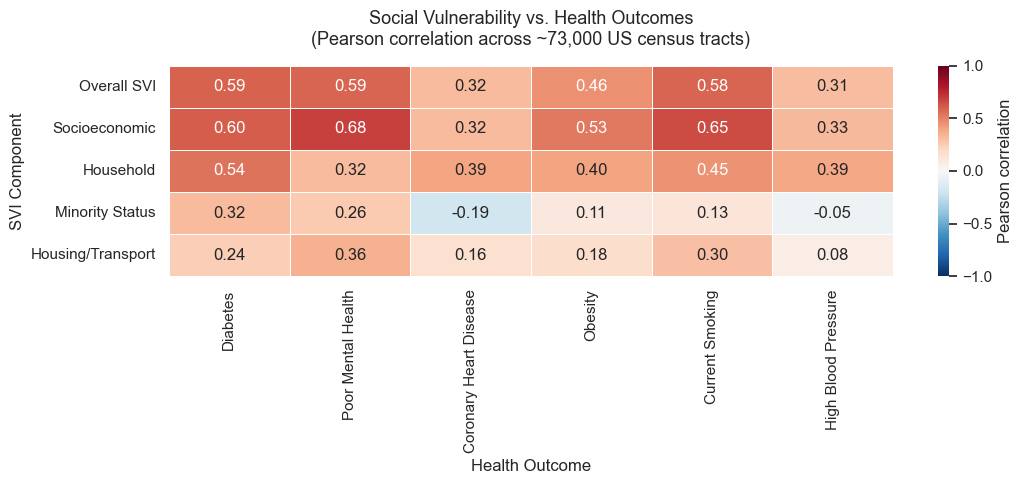

In [ ]:
svi_cols_list = ['svi_overall', 'svi_socioeconomic', 'svi_household', 'svi_minority', 'svi_housing']
outcome_cols = list(FOCUS_MEASURES.keys())

corr = df[svi_cols_list + outcome_cols].corr().loc[svi_cols_list, outcome_cols]

# Labels
corr.index = ['Overall SVI', 'Socioeconomic', 'Household', 'Minority Status', 'Housing/Transport']
corr.columns = [FOCUS_MEASURES[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson correlation'},
            ax=ax, linewidths=0.5)
ax.set_title('Social Vulnerability vs. Health Outcomes\n(Pearson correlation across ~73,000 US census tracts)',
             fontsize=13, pad=15)
ax.set_ylabel('SVI Component')
ax.set_xlabel('Health Outcome')
plt.tight_layout()
plt.savefig(OUTPUTS / 'figures' / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: The Scatter Plot

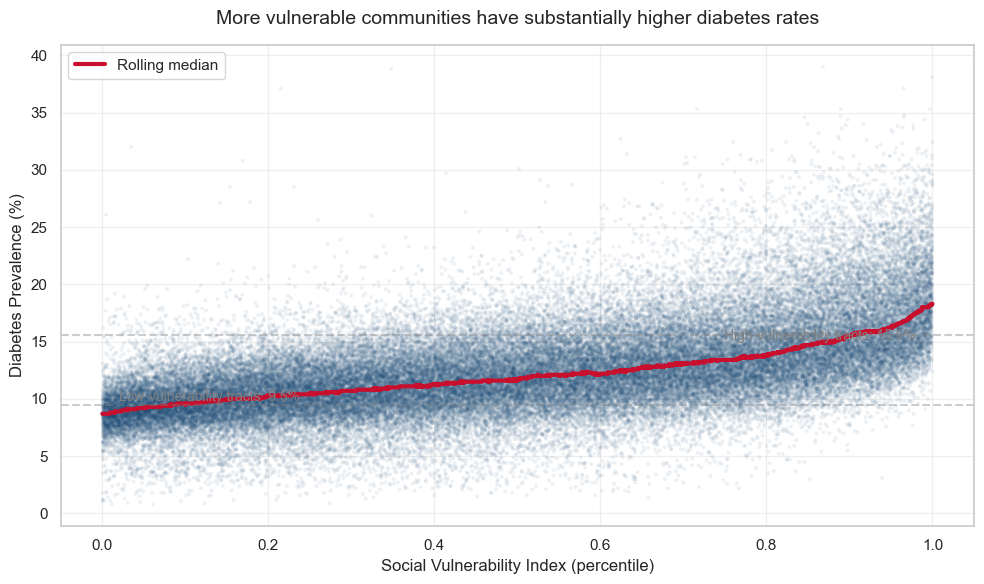


Diabetes prevalence in low-vulnerability tracts: 9.5%
Diabetes prevalence in high-vulnerability tracts: 15.6%
Ratio: 1.64x


In [60]:
# Diabetes vs. SVI - typically the strongest signal
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['svi_overall'], df['DIABETES'],
           alpha=0.08, s=8, color='#1f4e79', edgecolors='none')

# Trend line via rolling median (more robust than regression on this scale)
tmp = df[['svi_overall', 'DIABETES']].dropna().sort_values('svi_overall')
tmp['rolling_median'] = tmp['DIABETES'].rolling(2000, center=True, min_periods=500).median()
ax.plot(tmp['svi_overall'], tmp['rolling_median'],
        color='#c8102e', linewidth=3, label='Rolling median')

ax.set_xlabel('Social Vulnerability Index (percentile)', fontsize=12)
ax.set_ylabel('Diabetes Prevalence (%)', fontsize=12)
ax.set_title('More vulnerable communities have substantially higher diabetes rates',
             fontsize=14, pad=15)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Annotate the headline number
low_svi_diabetes = df[df['svi_overall'] < 0.2]['DIABETES'].median()
high_svi_diabetes = df[df['svi_overall'] > 0.8]['DIABETES'].median()
ax.axhline(low_svi_diabetes, color='gray', linestyle='--', alpha=0.4)
ax.axhline(high_svi_diabetes, color='gray', linestyle='--', alpha=0.4)
ax.text(0.02, low_svi_diabetes + 0.3, f'Low-vulnerability tracts: {low_svi_diabetes:.1f}%',
        fontsize=10, color='gray')
ax.text(0.98, high_svi_diabetes - 0.5, f'High-vulnerability tracts: {high_svi_diabetes:.1f}%',
        fontsize=10, color='gray', ha='right')

plt.tight_layout()
plt.savefig(OUTPUTS / 'figures' / 'diabetes_vs_svi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDiabetes prevalence in low-vulnerability tracts: {low_svi_diabetes:.1f}%')
print(f'Diabetes prevalence in high-vulnerability tracts: {high_svi_diabetes:.1f}%')
print(f'Ratio: {high_svi_diabetes / low_svi_diabetes:.2f}x')

### What This Shows

In this analysis, the relationship between socioeconomic vulnerability and adverse 
health outcomes is clear. Across ~73,000 US census tracts, the socioeconomic theme 
of the Social Vulnerability Index correlates with diabetes prevalence at r=0.60, 
poor mental health at r=0.68, and current smoking at r=0.65, the strongest signals 
observed across all SVI components. Translating this into concrete terms: census 
tracts in the highest vulnerability quintile show diabetes prevalence of 15.6%, 
compared to 9.5% in the lowest. This constitutes a 1.64x difference, consistent 
with findings in the broader literature. Bevan et al. (2024) documented a 66% 
increase in diabetes-related cardiovascular mortality associated with social 
vulnerability, and separately cited work by Khan et al. demonstrating an 84% 
increase in CVD deaths among vulnerable populations.

The Minority Status theme presents a more nuanced picture. Correlations with 
coronary heart disease (r=-0.19) and high blood pressure (r=-0.05) are near-zero 
or slightly negative, which appears counterintuitive given the well-documented 
relationship between minority status and adverse health outcomes in the broader 
literature. Two explanations are worth considering.

First, access barriers documented in the Hispanic Paradox literature offer a 
plausible mechanism. Structural obstacles including cost, provider availability, 
and healthcare avoidance reduce utilization among certain minority populations, 
producing artificially favorable health statistics for groups that may carry 
significant undiagnosed disease burden.

Second, cultural dietary patterns may contribute to genuinely improved cardiovascular 
outcomes in certain minority subpopulations. This remains speculative and would 
require further reading to support with any confidence.

It is also worth noting a methodological limitation in how these correlations were 
computed. The correlation matrix does not control for the socioeconomic theme, meaning 
the Minority Status signal reflects residual variance after socioeconomic vulnerability 
has already explained much of the outcome variation. More rigorous analysis — 
controlling for the observed interplay between socioeconomic status, ethnic background, 
and health outcomes — would be required to draw stronger conclusions about the 
independent relationship between minority status and the health outcomes examined here.

#### References
- Bevan, G. H., et al. (2024). *Journal of the American Heart Association*, 13(2). https://www.ahajournals.org/doi/10.1161/JAHA.123.029649
- HHS ASPE (2022). https://aspe.hhs.gov/sites/default/files/documents/e2b650cd64cf84aae8ff0fae7474af82/SDOH-Evidence-Review.pdf

## Step 7: State-Level Disparities

> **Phase 2 TODO:** This section surfaces initial geographic patterns in the 
> SVI→diabetes relationship across states. Interpretation and writeup deferred 
> to Phase 2, where a full geographic deep dive — including interactive maps, 
> urban/rural dimensions, and the "twin tracts" analysis — will provide the 
> necessary context to draw meaningful conclusions from these state-level 
> correlations.

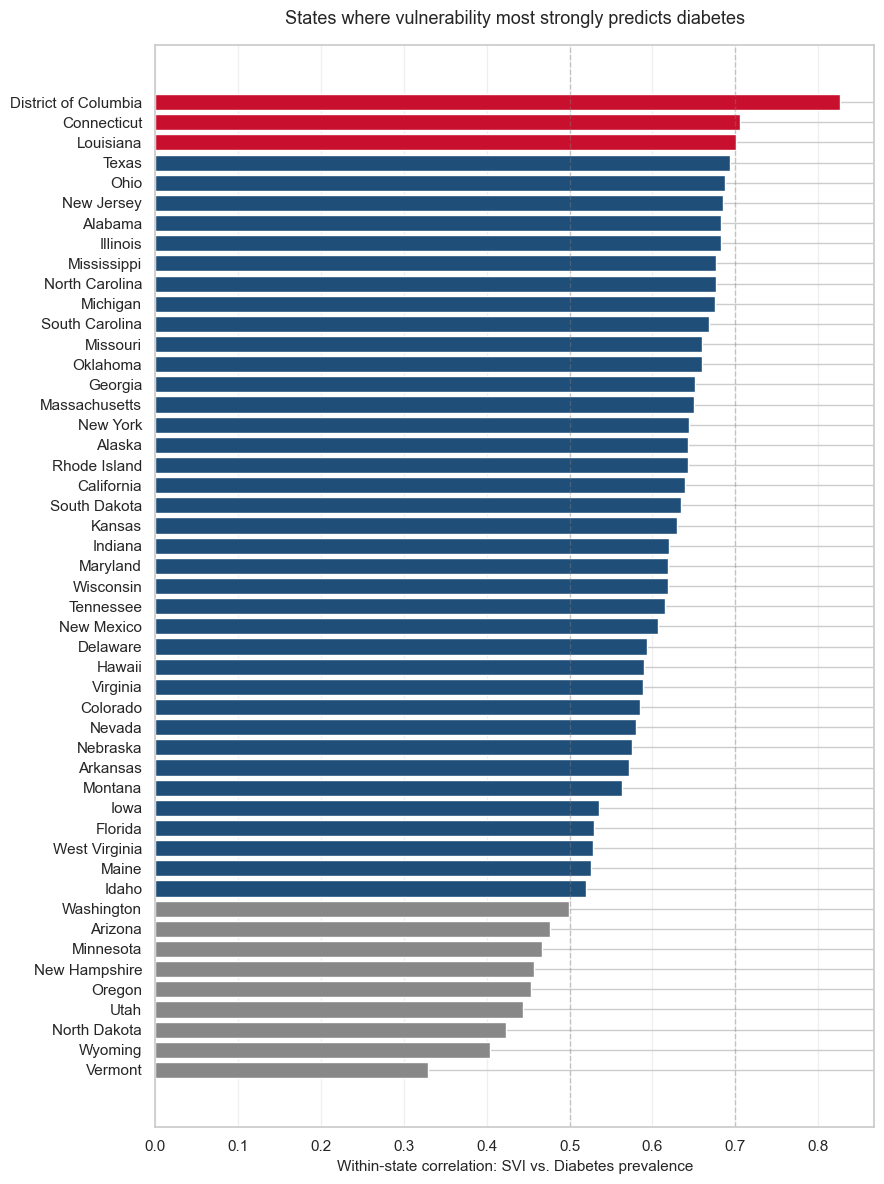

In [61]:
# For each state, compute the within-state correlation between SVI and diabetes
state_corr = (df.dropna(subset=['svi_overall', 'DIABETES'])
                .groupby('state')
                .apply(lambda g: g['svi_overall'].corr(g['DIABETES']))
                .sort_values(ascending=True)
                .rename('correlation')
                .reset_index())

fig, ax = plt.subplots(figsize=(9, 12))
colors = ['#c8102e' if c > 0.7 else '#1f4e79' if c > 0.5 else '#888' for c in state_corr['correlation']]
ax.barh(state_corr['state'], state_corr['correlation'], color=colors)
ax.set_xlabel('Within-state correlation: SVI vs. Diabetes prevalence', fontsize=11)
ax.set_title('States where vulnerability most strongly predicts diabetes',
             fontsize=13, pad=15)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'figures' / 'state_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 1 Summary

This analysis strongly supports the relationship between socioeconomic vulnerability 
and adverse health outcomes across US census tracts. The dominant signal is 
socioeconomic status, which correlates more strongly with diabetes, poor mental 
health, and smoking prevalence than any other SVI component. This is particularly 
meaningful given the longitudinal depth of census data — robust, geographically 
granular records of socioeconomic conditions over time may create a foundation for 
targeted outreach programs, and work such as Bevan et al. (2024) suggests that 
SVI-derived insights could inform both health and social interventions for at-risk 
communities.

The Minority Status theme warrants further exploration. Different minority groups 
experience radically different levels of access to health and social programs, and 
the analysis as constructed has no mechanism to control for this variance.

It is important to note that this study is observational in nature. The correlations 
documented here describe association, not causation, and should be interpreted 
accordingly. Phase 2 will explore the geographic distribution of these findings, 
examine the interplay between socioeconomic and geographic factors, and aim to paint 
a more complete picture of the conditions shaping health outcomes across the country.

#### References
- Bevan, G. H., et al. (2024). *Journal of the American Heart Association*, 13(2). https://www.ahajournals.org/doi/10.1161/JAHA.123.029649
- HHS ASPE (2022). https://aspe.hhs.gov/sites/default/files/documents/e2b650cd64cf84aae8ff0fae7474af82/SDOH-Evidence-Review.pdf